In [5]:
import torch 
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [6]:
# Device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Hyper parameters
num_epochs = 5
num_classes = 10
batch_size = 100
learning_rate = 0.001

# MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='data/',
                                           train=True, 
                                           transform=transforms.ToTensor(),
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='data/',
                                          train=False, 
                                          transform=transforms.ToTensor())

# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size, 
                                          shuffle=False)

Labels:  tensor([9, 3, 4, 8, 4, 8, 1, 2, 7, 0, 0, 0, 1, 8, 0, 4, 8, 2, 7, 1, 9, 2, 9, 6,
        3, 0, 6, 1, 2, 3, 0, 3, 6, 4, 3, 3, 0, 3, 2, 9, 9, 6, 4, 2, 6, 1, 5, 7,
        5, 5, 9, 0, 6, 6, 2, 6, 8, 9, 2, 0, 6, 4, 5, 0, 1, 9, 1, 3, 8, 2, 5, 0,
        7, 7, 3, 1, 3, 1, 0, 0, 6, 2, 0, 1, 1, 8, 6, 4, 4, 3, 7, 1, 9, 2, 0, 1,
        7, 4, 4, 9])
Batch shape:  torch.Size([100, 1, 28, 28])


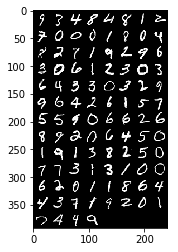

In [7]:
# Data visualization¶
# Let's explore the dataset, especially to determine the dimension of data.
def show_batch(batch):
    im = torchvision.utils.make_grid(batch)
    plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
    
dataiter = iter(train_loader)
images, labels = dataiter.next()

print('Labels: ', labels)
print('Batch shape: ', images.size())
show_batch(images)

In [20]:
# Convolutional neural network (two convolutional layers)
class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(  # input shape (1, 28, 28)
            nn.Conv2d(
                in_channels=1,        # input height 
                out_channels=16,      # n_filters
                kernel_size=5,        # filter size
                stride=1,             # filter movement/step
                padding=2             # padding=(kernel_size-1)/2
            ),                        # output shape (16, 28, 28)
            nn.BatchNorm2d(16),
            nn.ReLU(),                # activation
            nn.MaxPool2d(
                kernel_size=2, 
                stride=2
            )                         # output shape (16, 14, 14)
        )
        self.layer2 = nn.Sequential(  # input shape (16, 14, 14)
            nn.Conv2d(
                16, 32, 
                kernel_size=5, 
                stride=1, 
                padding=2
            ), # output shape (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)) # output shape (32, 7, 7)
        self.fc = nn.Linear(7*7*32, num_classes)   # fully connection layer, output 10 classes
        
    def forward(self, x):
        out = self.layer1(x) 
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

model = ConvNet(num_classes).to(device)
print(model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


In [21]:
# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

# Test the model
model.eval()  # eval mode (batchnorm uses moving mean/variance instead of mini-batch mean/variance)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Test Accuracy of the model on the 10000 test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Epoch [1/5], Step [100/600], Loss: 0.1209
Epoch [1/5], Step [200/600], Loss: 0.1608
Epoch [1/5], Step [300/600], Loss: 0.0600
Epoch [1/5], Step [400/600], Loss: 0.0518
Epoch [1/5], Step [500/600], Loss: 0.0630
Epoch [1/5], Step [600/600], Loss: 0.0599
Epoch [2/5], Step [100/600], Loss: 0.0347
Epoch [2/5], Step [200/600], Loss: 0.1492
Epoch [2/5], Step [300/600], Loss: 0.0635
Epoch [2/5], Step [400/600], Loss: 0.0421
Epoch [2/5], Step [500/600], Loss: 0.0151
Epoch [2/5], Step [600/600], Loss: 0.0092
Epoch [3/5], Step [100/600], Loss: 0.0584
Epoch [3/5], Step [200/600], Loss: 0.0372
Epoch [3/5], Step [300/600], Loss: 0.0181
Epoch [3/5], Step [400/600], Loss: 0.0092
Epoch [3/5], Step [500/600], Loss: 0.0217
Epoch [3/5], Step [600/600], Loss: 0.0572
Epoch [4/5], Step [100/600], Loss: 0.0243
Epoch [4/5], Step [200/600], Loss: 0.0046
Epoch [4/5], Step [300/600], Loss: 0.0366
Epoch [4/5], Step [400/600], Loss: 0.0511
Epoch [4/5], Step [500/600], Loss: 0.0246
Epoch [4/5], Step [600/600], Loss: